# Exercise 8-2: Do more analysis of the Awards data

## Read the data

In [52]:
import pandas as pd
import seaborn as sns

data_dir = '../../data'

In [53]:
awards_df = pd.read_pickle(f'{data_dir}/pkl_files/awards_data_2010_2025.pkl')

In [54]:
# Add a column for the year
awards_df['awd_year'] = awards_df['awd_eff_date'].apply(pd.to_datetime, errors='ignore').dt.year

In [55]:
# Rename inst.inst_state_code to inst_state_code
awards_df.rename(columns={'inst.inst_state_code': 'inst_state_code'}, inplace=True)

In [56]:
# Keep only columns of interest (dir_abbr, awd_year, inst_state_code, awd_amount)
awards_df = awards_df[['dir_abbr', 'awd_year', 'inst_state_code', 'awd_amount']]

In [57]:
# Add an awd_count column
awards_df['awd_count'] = 1

In [58]:
# Limit the awards data to the years 2014-2024
awards_df = awards_df.query('awd_year >= 2014 & awd_year <= 2024')

In [59]:
# Group and summarize the data
summarized_awards_df = awards_df.groupby(['dir_abbr', 'awd_year', 'inst_state_code']).agg(
    awd_amount=('awd_amount', 'sum'),
    awd_count=('awd_count', 'sum')
).reset_index()

In [61]:
summarized_awards_df.head()

,dir_abbr,awd_year,inst_state_code,awd_amount,awd_count
0,BFA,2014,DC,2875376.0,5
1,BFA,2014,WV,139094.0,1
2,BFA,2015,DC,703421.0,3
3,BFA,2015,WV,132262.0,1
4,BFA,2016,DC,942407.0,6


## Melt the data

In [ ]:
# Reshape the summarized_awards_df dataframe to a long format for easier visualization
awd_melt = summarized_awards_df.melt(id_vars=['dir_abbr','awd_year','inst_state_code'], 
                     value_vars=['awd_amount','awd_count'], 
                     var_name='feature')

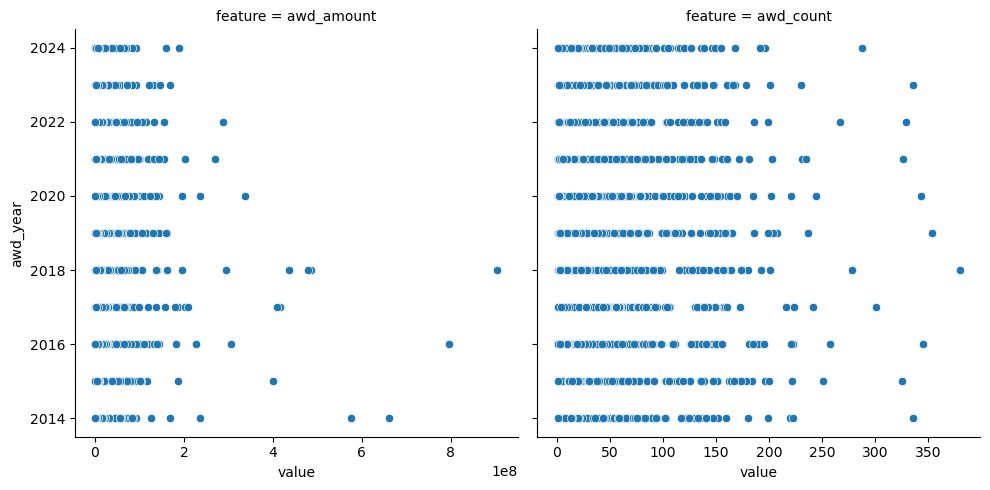

In [ ]:
# Create a relational plot to visualize the 'awd_melt' dataframe as a scatter plot
# with 'awd_year' on the y-axis and 'value' on the x-axis,
# and separate plots for each feature ('awd_amount' and 'awd_count')
sns.relplot(data=awd_melt, x='value', y='awd_year', 
            col='feature', facet_kws={'sharex':False})

## Rank the data by awd_amount

In [ ]:
# Add a column 'awd_rank' to rank the awards based on the 'awd_amount' column
awards_df['awd_rank'] = awards_df.awd_amount.rank()

In [ ]:
# Display the top 10 rows with the smallest award amounts
awards_df.sort_values('awd_amount').head(10)

,dir_abbr,awd_year,inst_state_code,awd_amount,awd_count,awd_rank
91080,O/D,2016,DC,-47492.0,1,1.0
164365,EDU,2023,TX,0.0,1,116.5
94148,MPS,2017,FL,0.0,1,116.5
58262,GEO,2014,CA,0.0,1,116.5
96012,SBE,2017,DC,0.0,1,116.5
133477,SBE,2020,VA,0.0,1,116.5
133343,MPS,2020,OH,0.0,1,116.5
133204,BFA,2020,DC,0.0,1,116.5
96575,SBE,2017,NY,0.0,1,116.5
57203,GEO,2015,,0.0,1,116.5


## Bin the data with quantiles

In [ ]:
# Use pd.qcut to bin the 'awd_amount' column into 3 quantile-based categories in a column named 'awd_level': 'low', 'medium', and 'high'
awards_df['awd_level'] = pd.qcut(awards_df.awd_amount, q=3, labels=['low', 'medium', 'high'])

In [ ]:
# Count the occurrences of each category in the 'awd_level' column
awards_df.awd_level.value_counts()

awd_level
low       45659
high      45165
medium    44671
Name: count, dtype: int64

## Group and aggregate the data

In [ ]:
# Group the awards data by 'awd_level' and calculate the minimum and maximum 'awd_amount' for each level
awards_df.groupby('awd_level', observed=False).awd_amount.agg(['min', 'max'])

,min,max
awd_level,,
low,-47492.0,200000.0
medium,200001.0,429108.0
high,429113.0,856494332.0


In [ ]:
# Group the awards data by 'dir_abbr', 'inst_state_code', and 'awd_year', 
# and calculate the mean of the 'awd_amount' column for each group
awards_df.groupby(['dir_abbr', 'inst_state_code', 'awd_year']).awd_amount.mean()

dir_abbr  inst_state_code  awd_year
BFA       DC               2014        5.750752e+05
                           2015        2.344737e+05
                           2016        1.570678e+05
                           2017        1.314308e+05
                           2018        2.002620e+05
                                           ...     
TIP       WY               2021        2.327925e+05
                           2022        2.657840e+05
                           2023        6.370495e+05
                           2024        6.261590e+06
          in               2014        2.549990e+05
Name: awd_amount, Length: 5159, dtype: float64

In [ ]:
# Group the awards data by 'dir_abbr', 'inst_state_code', and 'awd_year', 
# calculate the mean of the 'awd_amount' column for each group, 
# unstack the 'awd_year' index, and reset the index for a flat DataFrame
awards_df.groupby(['dir_abbr', 'inst_state_code', 'awd_year']).awd_amount.mean().unstack().reset_index()

awd_year,dir_abbr,inst_state_code,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,BFA,DC,575075.200000,234473.666667,157067.833333,131430.750000,200262.000000,243415.166667,213319.375000,213680.75,193806.909091,NaN,NaN
1,BFA,MD,NaN,NaN,44520.000000,44520.000000,69316.000000,69316.000000,102316.000000,106500.00,106500.000000,NaN,NaN
2,BFA,MS,NaN,NaN,NaN,NaN,490384.000000,NaN,NaN,NaN,NaN,NaN,NaN
3,BFA,OH,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BFA,TN,NaN,NaN,NaN,NaN,NaN,535197.333333,NaN,150000.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
514,TIP,WA,146874.125000,578808.333333,384306.391304,558088.400000,493496.695652,433052.235294,440200.571429,547665.04,948853.375000,630512.320000,4.121819e+05
515,TIP,WI,184580.357143,357195.066667,307610.473684,406827.285714,301225.400000,386903.100000,346346.666667,343705.30,635622.923077,295954.636364,2.537459e+05
516,TIP,WV,NaN,NaN,NaN,NaN,NaN,50000.000000,334650.000000,260526.00,50000.000000,347328.500000,3.340000e+05
517,TIP,WY,NaN,NaN,199976.666667,581593.750000,490261.000000,542474.666667,250420.000000,232792.50,265784.000000,637049.500000,6.261590e+06


In [ ]:
# Create a pivot table to summarize the number of awards ('awd_count') by year ('awd_year') and directorate ('dir_abbr')
awards_df.pivot_table(index='awd_year', columns='dir_abbr', values='awd_count', aggfunc='sum')

dir_abbr,BFA,BIO,CSE,EDU,ENG,GEO,IRM,MPS,NCO,NNCO,NSB,O/D,OCIO,OPP,SBE,TIP
awd_year,,,,,,,,,,,,,,,,
2014,6.0,1329.0,1796.0,911.0,1770.0,1546.0,9.0,2503.0,1.0,NaN,6.0,360.0,NaN,1.0,1056.0,689.0
2015,4.0,1426.0,2070.0,1035.0,1955.0,1630.0,11.0,2698.0,NaN,1.0,2.0,320.0,NaN,NaN,1101.0,673.0
2016,8.0,1424.0,2072.0,1143.0,1839.0,1615.0,13.0,2569.0,NaN,NaN,7.0,290.0,1.0,NaN,1043.0,967.0
2017,8.0,1231.0,2015.0,1106.0,1855.0,1539.0,25.0,2475.0,NaN,1.0,1.0,250.0,NaN,NaN,1092.0,596.0
2018,11.0,1251.0,2159.0,1157.0,1926.0,1502.0,19.0,2740.0,1.0,1.0,5.0,128.0,NaN,NaN,986.0,716.0
2019,11.0,1050.0,2189.0,1047.0,1754.0,1567.0,17.0,2595.0,1.0,1.0,2.0,125.0,1.0,NaN,909.0,843.0
2020,10.0,1365.0,2115.0,1187.0,1709.0,1613.0,18.0,2605.0,NaN,NaN,4.0,127.0,NaN,NaN,1104.0,873.0
2021,11.0,1259.0,1906.0,1198.0,1610.0,1698.0,27.0,2534.0,NaN,NaN,2.0,170.0,1.0,NaN,924.0,904.0
2022,13.0,1198.0,2027.0,1211.0,1721.0,1465.0,15.0,2575.0,NaN,NaN,7.0,161.0,1.0,NaN,839.0,804.0


<Axes: xlabel='awd_year'>

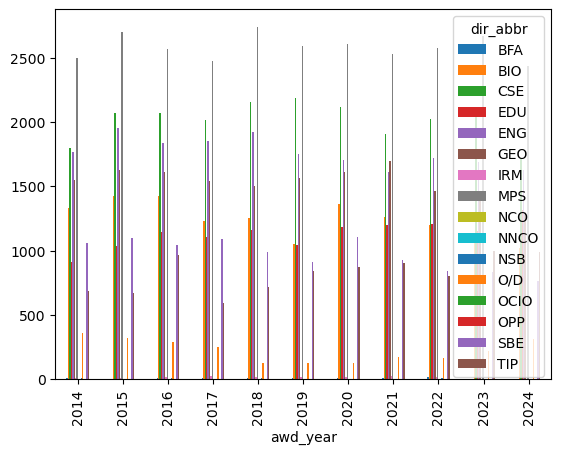

In [ ]:
# Create a pivot table to summarize the number of awards ('awd_count') by year ('awd_year') and directorate ('dir_abbr'),
# and visualize the result as a bar plot
awards_df.pivot_table(index='awd_year', columns='dir_abbr', values='awd_count', aggfunc='sum').plot.bar()

## Similar, by award type

In [73]:
awards_w_type_df = pd.read_pickle(f'{data_dir}/pkl_files/awards_with_type_df.pkl')

In [78]:
# Add a column for the year
awards_w_type_df['awd_year'] = awards_w_type_df['awd_eff_date'].dt.year
# Add a column for awd_count
awards_w_type_df['awd_count'] = 1

In [79]:
# Only keep the things we need
awards_w_type_df = awards_w_type_df[['awd_year', 'awd_count', 'awd_amount', 'awd_type']]

<Axes: xlabel='awd_year'>

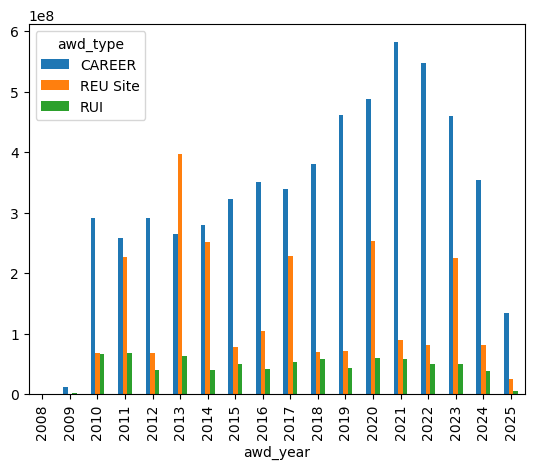

In [82]:
awards_w_type_df.pivot_table(index='awd_year', columns='awd_type', values='awd_amount', aggfunc='sum').plot.bar()